In [44]:
#install.packages('haven')
#install.packages('dplyr')
#install.packages("devtools")
#devtools::install_github("MathiasHarrer/dmetar")

In [45]:
# References
# https://bookdown.org/MathiasHarrer/Doing_Meta_Analysis_in_R/discovering-R.html
# https://rpubs.com/gilbertlzrus/meta-analysis-in-R

library(haven); library(dplyr); library(ggplot2)


In [46]:
data <- read_dta('example1.dta')

In [47]:
data
# a = the number of people with the outcome in the treatment group
# r1 = the total number of people in the treatment group
# c = the number of people with the outcome in the control group
# r2 = the total number of people in the control group

name,year,a,r1,c,r2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Slama,1990,1,104,1,106
Porter,1972,5,101,4,90
Demers,1990,15,292,5,292
Stewart,1982,11,504,4,187
Page,1986,8,114,5,68
Slama,1995,42,2199,5,929
Haug,1994,20,154,7,109
Russell,1979,34,1031,8,1107
Wilson,1982,21,106,11,105


In [48]:
data$'b' <- data$'r1' - data$'a'
data$'d' <- data$'r2' - data$'c'

In [49]:
data

name,year,a,r1,c,r2,b,d
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Slama,1990,1,104,1,106,103,105
Porter,1972,5,101,4,90,96,86
Demers,1990,15,292,5,292,277,287
Stewart,1982,11,504,4,187,493,183
Page,1986,8,114,5,68,106,63
Slama,1995,42,2199,5,929,2157,924
Haug,1994,20,154,7,109,134,102
Russell,1979,34,1031,8,1107,997,1099
Wilson,1982,21,106,11,105,85,94


In [50]:
??forest.meta

R Information

Help files with alias or concept or title matching ‘forest.meta’ using
regular expression matching:


meta::forest.meta       Forest plot to display the result of a
                        meta-analysis
  Aliases: forest.meta
meta::forest.metabind   Forest plot to display the result of a
                        meta-analysis
  Aliases: forest.metabind


Type '?PKG::FOO' to inspect entries 'PKG::FOO', or 'TYPE?PKG::FOO' for
entries like 'PKG::FOO-TYPE'.




In [51]:
library(meta)

In [52]:
m.publ = metabin(data$'a', 
                 data$'r1',
                 data$'c',
                 data$'r2',
                 sm="OR" #, label.left = paste(data$'name', ', ', data$'year')
                        )

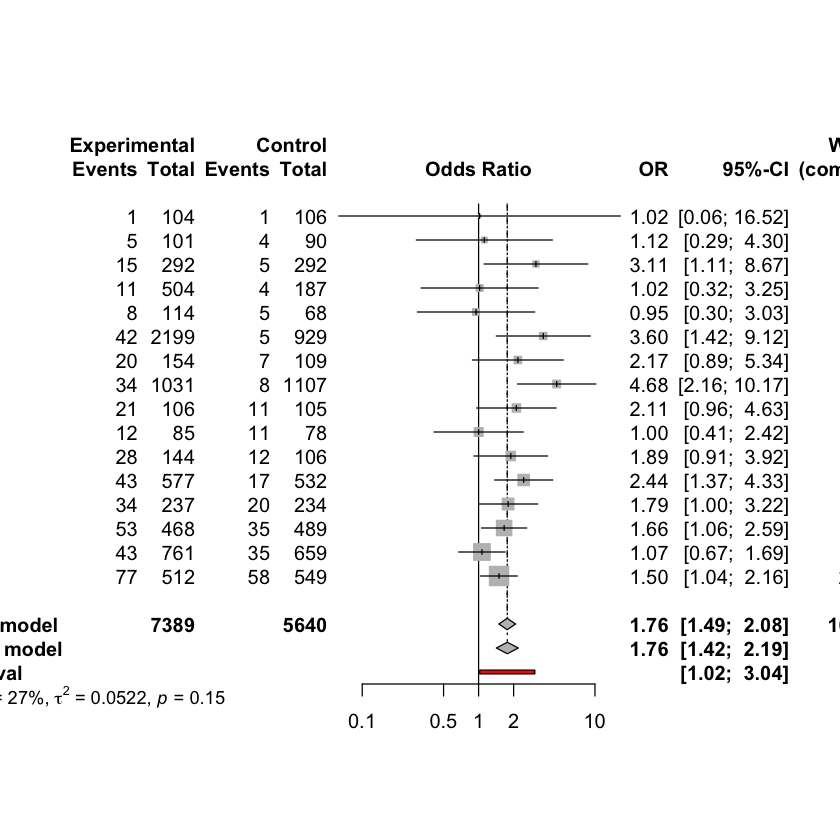

In [53]:
forest(m.publ, prediction = TRUE)

In [54]:
paste(data$'name', ', ', data$'year')

[1] "Slama ,  1990"    "Porter ,  1972"   "Demers ,  1990"   "Stewart ,  1982" 
 [5] "Page ,  1986"     "Slama ,  1995"    "Haug ,  1994"     "Russell ,  1979" 
 [9] "Wilson ,  1982"   "McDowell ,  1985" "Janz ,  1987"     "Wilson ,  1990"  
[13] "Vetter ,  1990"   "Higashi ,  1995"  "Russell ,  1983"  "Jamrozik ,  1984"

In [55]:
bcgdata <- read_dta('bcgtrial.dta')
bcgdata

trial,trialnam,authors,startyr,latitude,alloc,tcases,tnoncases,ccases,cnoncases,ttotal,ctotal
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl+lbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,Canada,Ferguson & Simes,1933,55,0,6,300,29,274,306,303
1,Northern USA,Aronson,1935,52,0,4,119,11,128,123,139
8,Chicago,Rosenthal et al,1941,42,1,17,1699,65,1600,1716,1665
10,Georgia (Sch),Comstock & Webster,1947,33,1,5,2493,3,2338,2498,2341
9,Puerto Rico,Comstock et al,1949,18,1,186,50448,141,27197,50634,27338
11,Georgia (Comm),Comstock et al.,1950,33,1,27,16886,29,17825,16913,17854
4,Madanapalle,Frimont-Moller et al,1950,13,1,33,5036,47,5761,5069,5808
3,UK,Hart & Sutherland,1950,53,0,62,13536,248,12619,13598,12867
7,South Africa,Coetzee & Berjak,1965,27,0,29,7470,45,7232,7499,7277


In [56]:
bcgdata.publ = metabin(bcgdata$'tcases', 
                 bcgdata$'ttotal',
                 bcgdata$'ccases',
                 bcgdata$'ctotal',
                 sm="OR" #, label.left = paste(data$'name', ', ', data$'year')
                        )

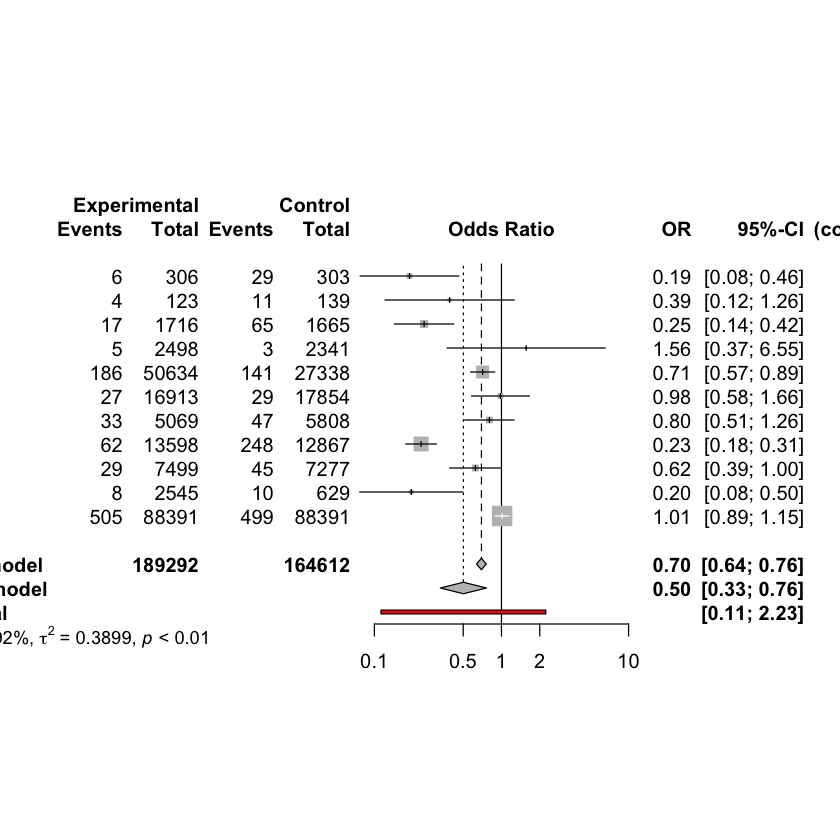

In [57]:
forest(bcgdata.publ, prediction = TRUE)

In [58]:
bcgdata.publ = metabin(tcases, 
                 ttotal,
                 ccases,
                 ctotal,
                 sm="OR",
                 data = bcgdata, 
                 studlab = paste0(authors, ', ', startyr),
                 method.tau = "PM"
                        )
bcgdata.publ

Number of studies combined: k = 11
Number of observations: o = 353904
Number of events: e = 2009

                         OR           95%-CI     z  p-value
Common effect model  0.6955 [0.6363; 0.7601] -8.01 < 0.0001
Random effects model 0.5013 [0.3287; 0.7645] -3.21   0.0013

Quantifying heterogeneity:
 tau^2 = 0.3991 [0.1446; 1.5368]; tau = 0.6318 [0.3803; 1.2397]
 I^2 = 92.1% [87.9%; 94.9%]; H = 3.56 [2.87; 4.42]

Test of heterogeneity:
      Q d.f.  p-value
 126.98   10 < 0.0001

Details on meta-analytical method:
- Mantel-Haenszel method
- Paule-Mandel estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau

In [59]:
pdf("forest-m1.pdf", width = 12, height = 5)
forest(bcgdata.publ,
       label.left = "Favours placebo" , 
       label.right = "Favours treatment")
dev.off()

pdf 
  2

In [60]:
pdf("forest-m2.pdf", width = 12, height = 5)
forest(bcgdata.publ,
       label.left = "Favours placebo" , 
       label.right = "Favours treatment",
       prediction = TRUE)
dev.off()

pdf 
  2

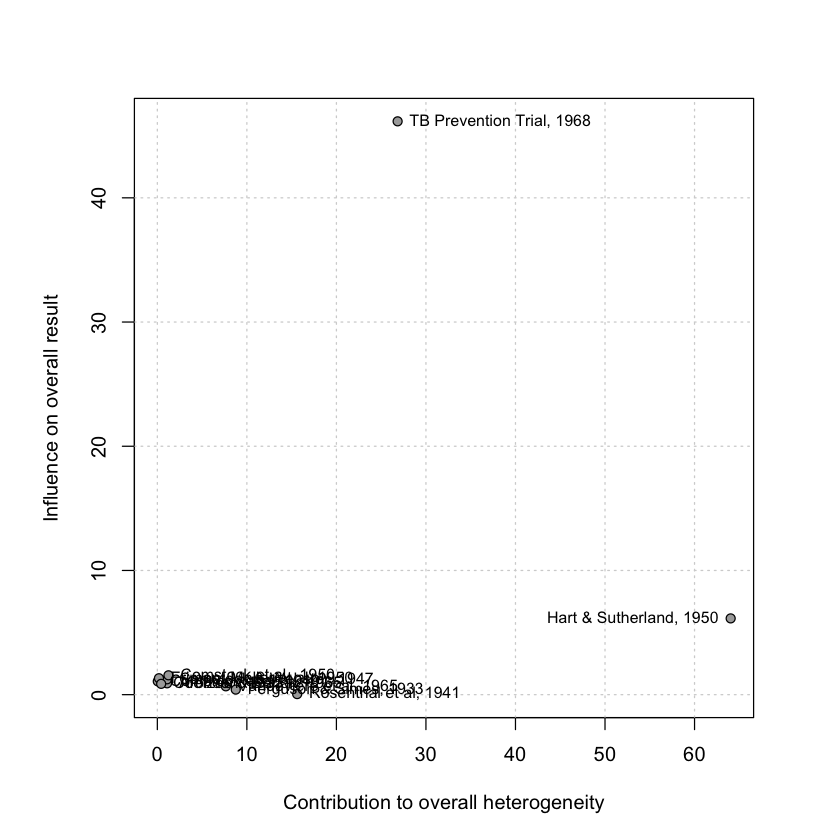

In [61]:
baujat(bcgdata.publ)

[1] 126.9752

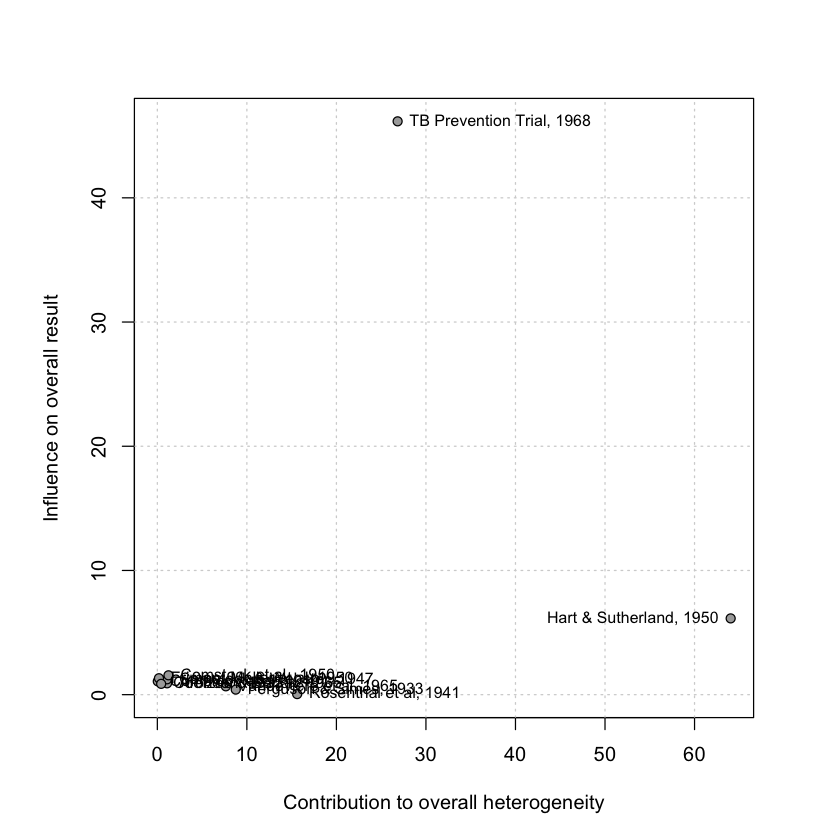

In [62]:
sum(baujat(bcgdata.publ)$x)

In [63]:
bcgdata

trial,trialnam,authors,startyr,latitude,alloc,tcases,tnoncases,ccases,cnoncases,ttotal,ctotal
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl+lbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,Canada,Ferguson & Simes,1933,55,0,6,300,29,274,306,303
1,Northern USA,Aronson,1935,52,0,4,119,11,128,123,139
8,Chicago,Rosenthal et al,1941,42,1,17,1699,65,1600,1716,1665
10,Georgia (Sch),Comstock & Webster,1947,33,1,5,2493,3,2338,2498,2341
9,Puerto Rico,Comstock et al,1949,18,1,186,50448,141,27197,50634,27338
11,Georgia (Comm),Comstock et al.,1950,33,1,27,16886,29,17825,16913,17854
4,Madanapalle,Frimont-Moller et al,1950,13,1,33,5036,47,5761,5069,5808
3,UK,Hart & Sutherland,1950,53,0,62,13536,248,12619,13598,12867
7,South Africa,Coetzee & Berjak,1965,27,0,29,7470,45,7232,7499,7277


Number of studies combined: k = 6
Number of observations: o = 222068
Number of events: e = 1456

                         OR           95%-CI     z  p-value
Common effect model  0.7084 [0.6383; 0.7863] -6.48 < 0.0001
Random effects model 0.3858 [0.2171; 0.6855] -3.25   0.0012

Quantifying heterogeneity:
 tau^2 = 0.3991 [0.1250; 2.7538]; tau = 0.6318 [0.3536; 1.6594]
 I^2 = 95.4% [92.3%; 97.2%]; H = 4.66 [3.60; 6.03]

Test of heterogeneity:
      Q d.f.  p-value
 108.55    5 < 0.0001

Details on meta-analytical method:
- Mantel-Haenszel method
- Paule-Mandel estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau

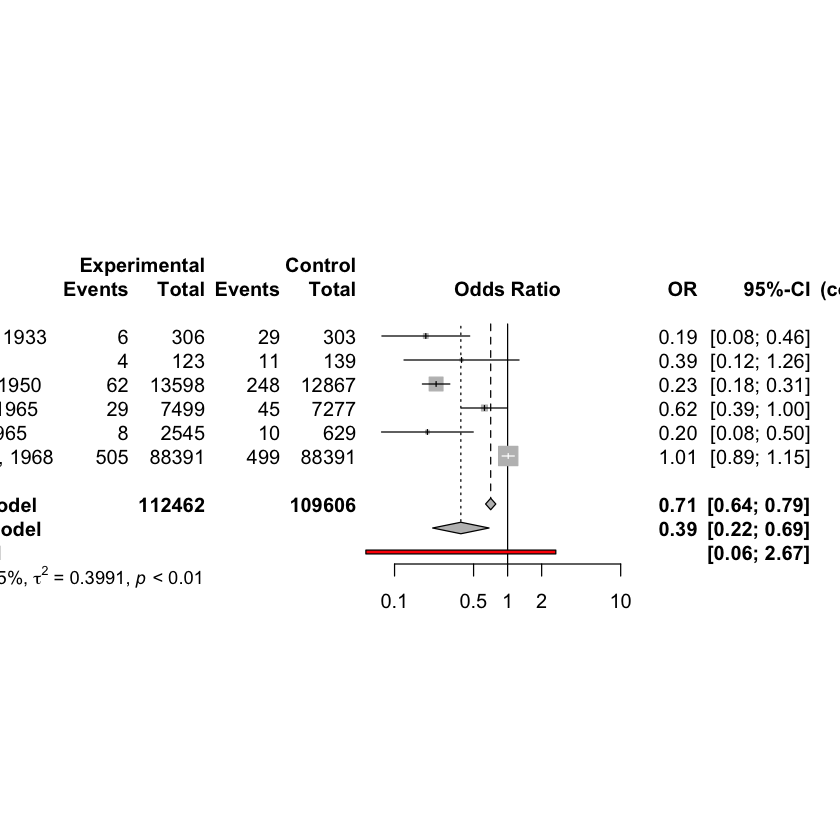

In [64]:
bcgdata.alloc.publ = metabin(tcases, 
                 ttotal,
                 ccases,
                 ctotal,
                 sm="OR",
                 data = bcgdata[bcgdata$alloc == 0, ], 
                 studlab = paste0(authors, ', ', startyr),
                 method.tau = "PM"
                        )
bcgdata.alloc.publ
forest(bcgdata.alloc.publ, prediction = TRUE)

Number of studies combined: k = 5
Number of observations: o = 131836
Number of events: e = 553

                         OR           95%-CI     z  p-value
Common effect model  0.6613 [0.5580; 0.7838] -4.77 < 0.0001
Random effects model 0.6748 [0.3876; 1.1748] -1.39   0.1644

Quantifying heterogeneity:
 tau^2 = 0.3029 [0.0457; 3.6286]; tau = 0.5503 [0.2138; 1.9049]
 I^2 = 77.2% [44.9%; 90.6%]; H = 2.10 [1.35; 3.26]

Test of heterogeneity:
     Q d.f. p-value
 17.56    4  0.0015

Details on meta-analytical method:
- Mantel-Haenszel method
- Paule-Mandel estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau

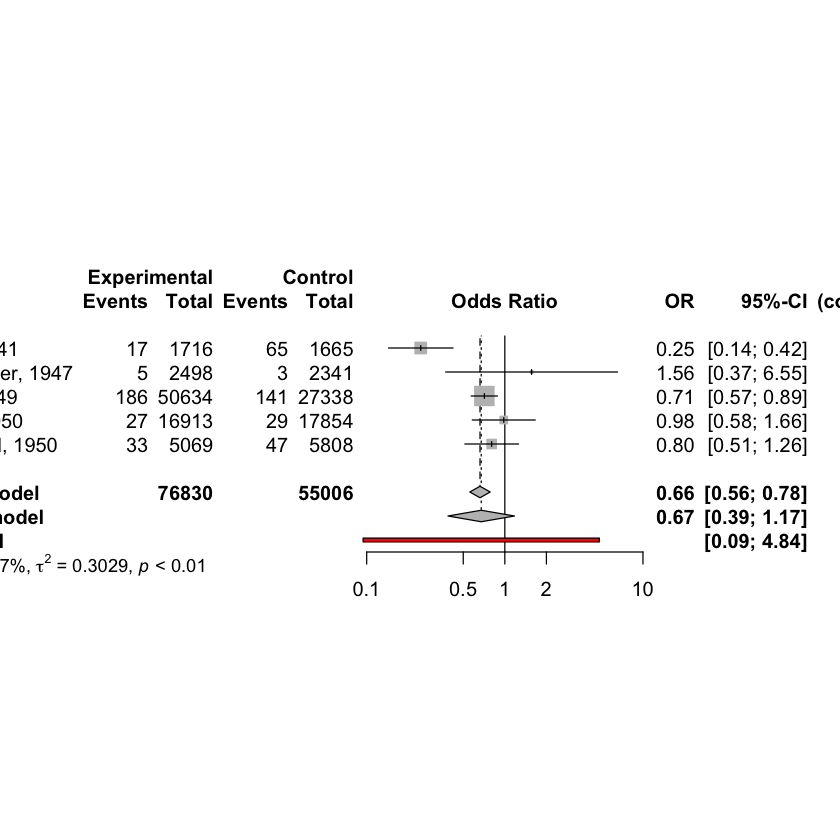

In [65]:
bcgdata.alloc.publ = metabin(tcases, 
                 ttotal,
                 ccases,
                 ctotal,
                 sm="OR",
                 data = bcgdata[bcgdata$alloc == 1, ], 
                 studlab = paste0(authors, ', ', startyr),
                 method.tau = "PM"
                        )
bcgdata.alloc.publ
forest(bcgdata.alloc.publ, prediction = TRUE)

In [66]:
bcgdata.latitude.publ = metareg(~latitude, 
                 sm="OR",
                 x = bcgdata.publ,
                 method.tau = "PM"
                        )
bcgdata.latitude.publ

Warning message:
“Extra argument ('sm') disregarded.”



Mixed-Effects Model (k = 11; tau^2 estimator: PM)

tau^2 (estimated amount of residual heterogeneity):     0.2114 (SE = 0.1451)
tau (square root of estimated tau^2 value):             0.4598
I^2 (residual heterogeneity / unaccounted variability): 83.79%
H^2 (unaccounted variability / sampling variability):   6.17
R^2 (amount of heterogeneity accounted for):            47.03%

Test for Residual Heterogeneity:
QE(df = 9) = 23.7284, p-val = 0.0048

Test of Moderators (coefficient 2):
QM(df = 1) = 6.8826, p-val = 0.0087

Model Results:

          estimate      se     zval    pval    ci.lb    ci.ub     
intrcpt     0.1903  0.3691   0.5156  0.6062  -0.5331   0.9136     
latitude   -0.0283  0.0108  -2.6235  0.0087  -0.0494  -0.0072  ** 

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


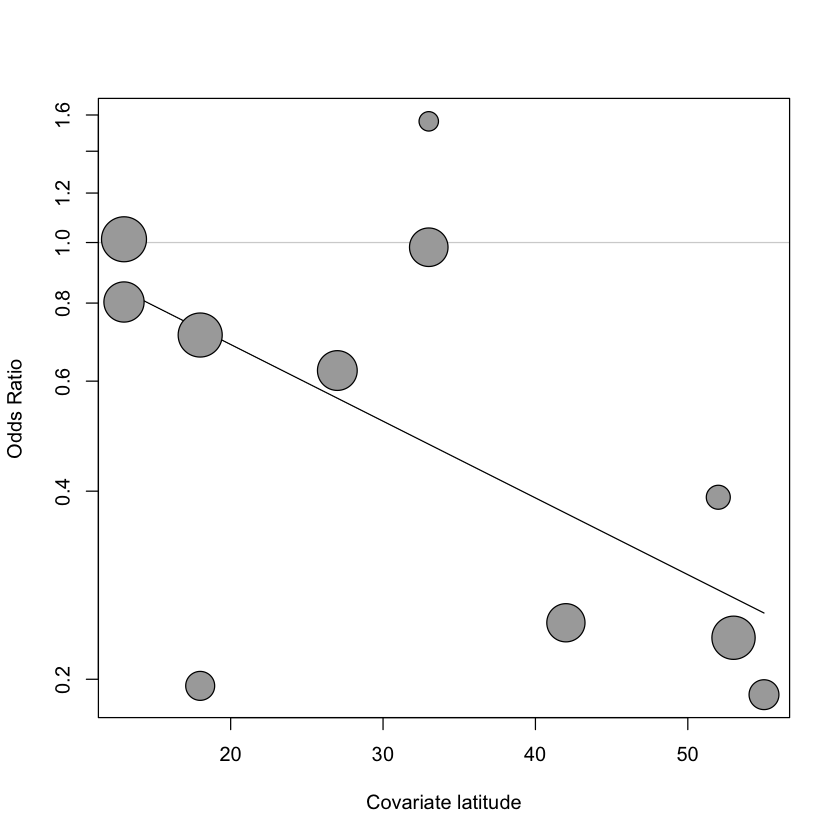

In [67]:
bubble(bcgdata.latitude.publ)

In [68]:
# update(bcgdata.publ, subgroup = latitude)
bcgdata.publ = metabin(tcases, 
                 ttotal,
                 ccases,
                 ctotal,
                 sm="OR",
                 data = bcgdata, 
                 studlab = paste0(authors, ', ', startyr),
                 method.tau = "PM"
                        )
bcgdata.publ

Number of studies combined: k = 11
Number of observations: o = 353904
Number of events: e = 2009

                         OR           95%-CI     z  p-value
Common effect model  0.6955 [0.6363; 0.7601] -8.01 < 0.0001
Random effects model 0.5013 [0.3287; 0.7645] -3.21   0.0013

Quantifying heterogeneity:
 tau^2 = 0.3991 [0.1446; 1.5368]; tau = 0.6318 [0.3803; 1.2397]
 I^2 = 92.1% [87.9%; 94.9%]; H = 3.56 [2.87; 4.42]

Test of heterogeneity:
      Q d.f.  p-value
 126.98   10 < 0.0001

Details on meta-analytical method:
- Mantel-Haenszel method
- Paule-Mandel estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau

In [69]:
bcgdata_metareg <- update(bcgdata.publ, subgroup = latitude)
pdf("forest-metareg.pdf", width = 12, height = 12)
forest(bcgdata_metareg,
       label.left = "Favours placebo" , 
       label.right = "Favours treatment",
       subgroup = TRUE
       )
dev.off()

pdf 
  2

In [70]:
update(bcgdata.publ, subgroup = latitude)

Number of studies combined: k = 11
Number of observations: o = 353904
Number of events: e = 2009

                         OR           95%-CI     z  p-value
Common effect model  0.6955 [0.6363; 0.7601] -8.01 < 0.0001
Random effects model 0.5013 [0.3287; 0.7645] -3.21   0.0013

Quantifying heterogeneity:
 tau^2 = 0.3991 [0.1446; 1.5368]; tau = 0.6318 [0.3803; 1.2397]
 I^2 = 92.1% [87.9%; 94.9%]; H = 3.56 [2.87; 4.42]

Test of heterogeneity:
      Q d.f.  p-value
 126.98   10 < 0.0001

Results for subgroups (common effect model):
                k     OR           95%-CI    Q   I^2
latitude = 55   1 0.1890 [0.0773; 0.4621] 0.00    --
latitude = 52   1 0.3911 [0.1212; 1.2619] 0.00    --
latitude = 42   1 0.2463 [0.1438; 0.4219] 0.00    --
latitude = 33   2 1.0402 [0.6367; 1.6993] 0.36  0.0%
latitude = 18   2 0.6696 [0.5413; 0.8284] 6.98 85.7%
latitude = 13   2 0.9952 [0.8832; 1.1215] 0.95  0.0%
latitude = 53   1 0.2331 [0.1763; 0.3082] 0.00    --
latitude = 27   1 0.6239 [0.3908; 0.9961]

In [71]:
magnes_data <- read_dta('magnes.dta')
magnes_data

trial,trialnam,year,tot1,dead1,tot0,dead0
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Morton,1984,40,1,36,2
2,Rasmussen,1986,135,9,135,23
3,Smith,1986,200,2,200,7
4,Abraham,1987,48,1,46,1
5,Feldstedt,1988,150,10,148,8
6,Schechter,1989,59,1,56,9
7,Ceremuzynski,1989,25,1,23,3
8,Bertschat,1989,22,0,21,1
9,Singh,1990,76,6,75,11


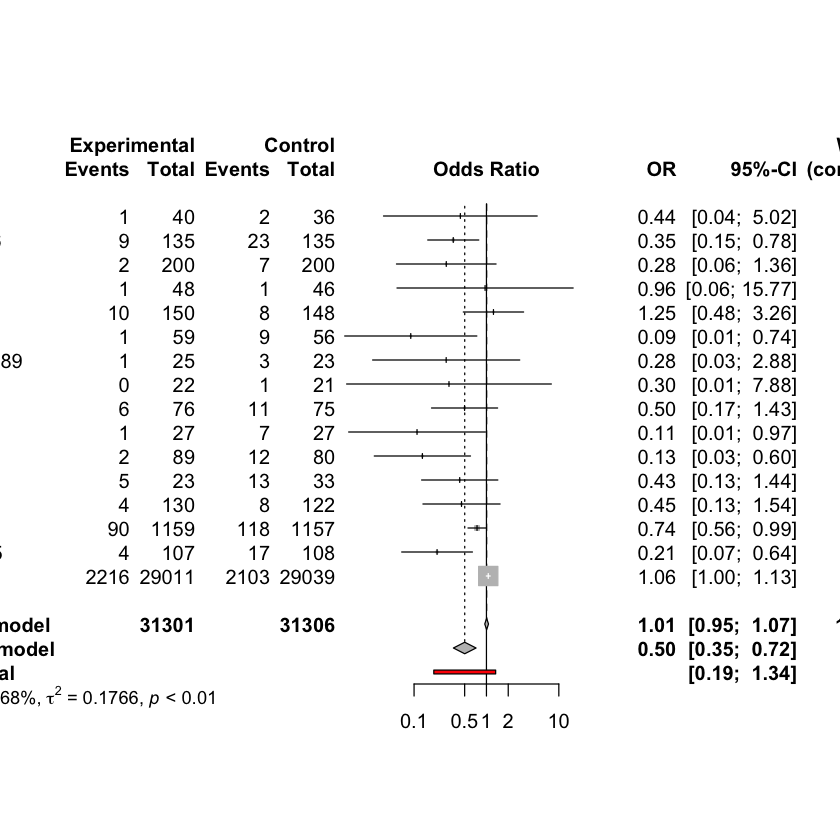

In [72]:
magnes.publ = metabin(dead1, 
                 tot1,
                 dead0,
                 tot0,
                 sm="OR",
                 data = magnes_data, 
                 studlab = paste0(trialnam, ', ', year),
                 method.tau = "PM"
                        )
forest(magnes.publ, prediction = TRUE)

In [73]:
pdf("magnes-forest.pdf", width = 12, height = 12)
forest(magnes.publ,
       label.left = "Favours treatment" , 
       label.right = "Favours placebo",
       prediction = TRUE
       )
dev.off()

pdf 
  2

In [74]:
magnes.year.publ = metareg(~year, 
                 sm="OR",
                 x = magnes.publ,
                 method.tau = "PM"
                        )
magnes.year.publ

Warning message:
“Extra argument ('sm') disregarded.”



Mixed-Effects Model (k = 16; tau^2 estimator: PM)

tau^2 (estimated amount of residual heterogeneity):     0.1722 (SE = 0.2017)
tau (square root of estimated tau^2 value):             0.4149
I^2 (residual heterogeneity / unaccounted variability): 48.59%
H^2 (unaccounted variability / sampling variability):   1.95
R^2 (amount of heterogeneity accounted for):            2.49%

Test for Residual Heterogeneity:
QE(df = 14) = 23.2112, p-val = 0.0569

Test of Moderators (coefficient 2):
QM(df = 1) = 1.1669, p-val = 0.2800

Model Results:

          estimate        se     zval    pval      ci.lb     ci.ub    
intrcpt  -125.0042  115.0851  -1.0862  0.2774  -350.5669  100.5584    
year        0.0624    0.0578   1.0802  0.2800    -0.0509    0.1757    

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


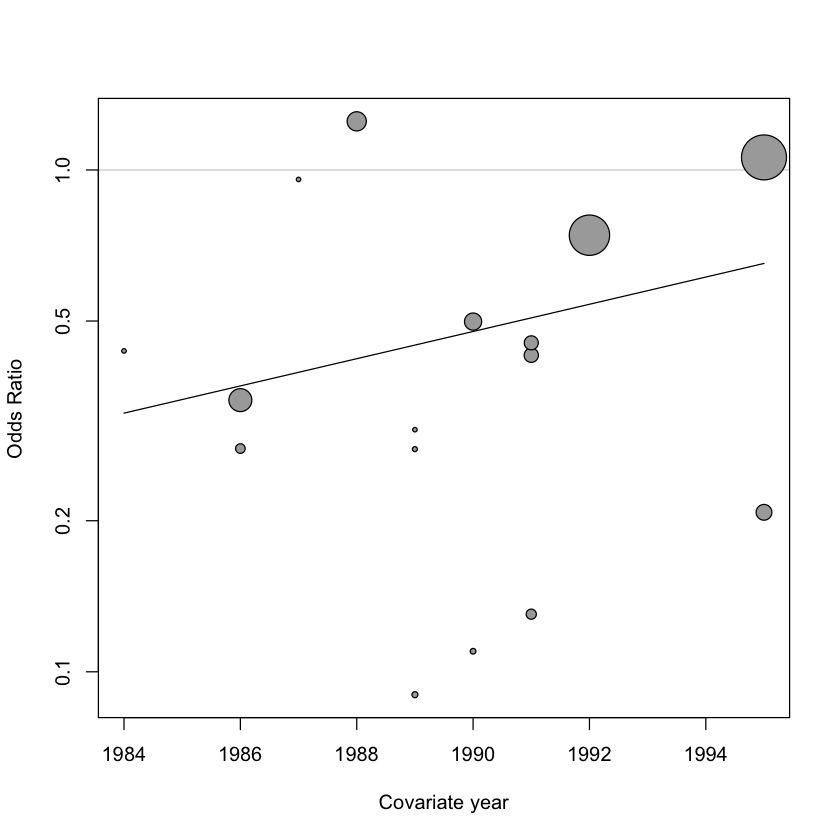

In [75]:
bubble(magnes.year.publ)

Linear regression test of funnel plot asymmetry

Test result: t = -5.69, df = 14, p-value < 0.0001

Sample estimates:
    bias se.bias intercept se.intercept
 -1.7525  0.3077    0.1029       0.0374

Details:
- multiplicative residual heterogeneity variance (tau^2 = 1.2018)
- predictor: standard error of score
- weight:    inverse variance of score
- reference: Harbord et al. (2006), Stat Med

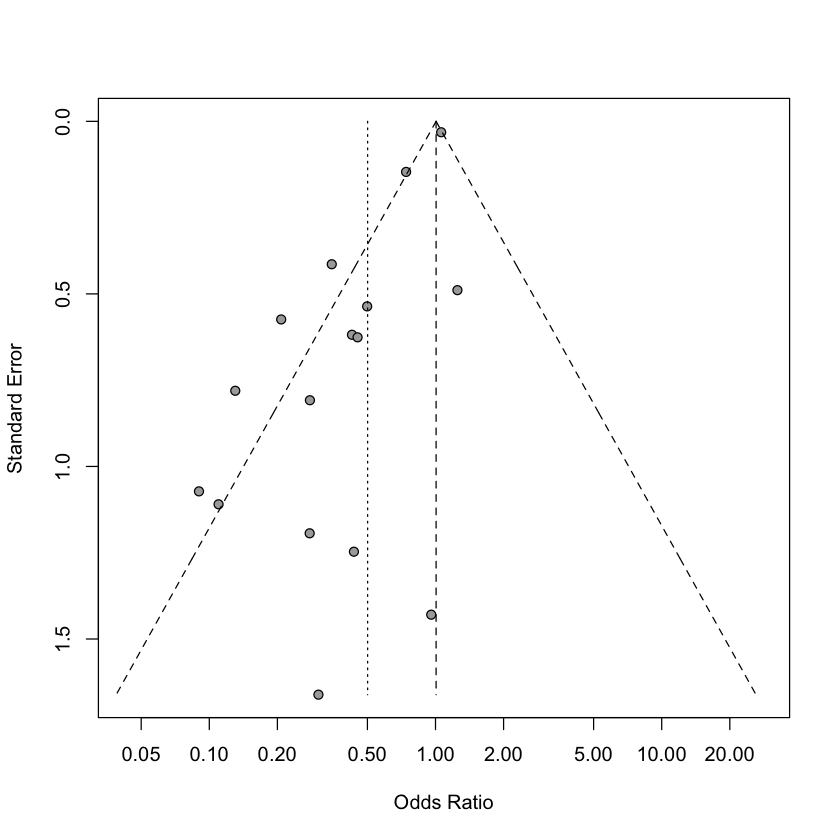

In [76]:
metabias(magnes.publ)
funnel(magnes.publ)

In [77]:
pdf("magnes-funnel.pdf", width = 12, height = 12)
funnel(magnes.publ)+theme_classic()
dev.off()

NULL

pdf 
  2